In [1]:
# Importing necessary packages 
import pandas as pd
import numpy as np
import seaborn as sns; sns.set(color_codes=True)
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")
from sklearn.preprocessing import LabelEncoder,OneHotEncoder




In [2]:
# Importing dataset

policy = pd.read_excel("Account Management Case Study.xlsx", sheet_name="Policy Data")
claims = pd.read_excel("Account Management Case Study.xlsx", sheet_name="Claims Data")

## Retreiving and creating dfs for Policy Data Tables 

In [3]:
# Extracting Quarterly total Policies 

df_QTP = policy.iloc[1:51, 3:8]
df_QTP .head()

,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7
1,Year,Quarter,Total Written Policies (000s),Total Written Premium (£m),Average Premium (£)
2,2012,Q1,3045.437767,971.971985,319.156738
3,2012,Q2,2964.701445,968.617216,326.716613
4,2012,Q3,3082.795986,1038.401851,336.837681
5,2012,Q4,3191.474459,1072.001328,335.895318


In [4]:
# Make the first row as header
df_QTP.columns = df_QTP.iloc[0]    # set first row as header
df_QTP = df_QTP.drop(df_QTP.index[0])  # drop the row used as header

# Reset index for cleanliness
df_QTP = df_QTP.reset_index(drop=True)

df_QTP.head()


1,Year,Quarter,Total Written Policies (000s),Total Written Premium (£m),Average Premium (£)
0,2012,Q1,3045.437767,971.971985,319.156738
1,2012,Q2,2964.701445,968.617216,326.716613
2,2012,Q3,3082.795986,1038.401851,336.837681
3,2012,Q4,3191.474459,1072.001328,335.895318
4,2013,Q1,3008.802629,1006.098809,334.385114


In [5]:
df_QTP.to_excel("Insurance Data.xlsx", sheet_name="Quaterly Total Policy", index=False)

In [6]:
# Extracting New Buisness Data 
df_NBD = policy.iloc[1:18, 11:16]
df_NBD.columns = df_NBD.iloc[0]    # set first row as header
df_NBD = df_NBD.drop(df_NBD.index[0])  # drop the row used as header

# Reset index for cleanliness
df_NBD = df_NBD.reset_index(drop=True)

df_NBD.head()


1,Year,Quarter,Number of policies (000s),Written premiums (£m),Average Premium (£)
0,2020,Q1,830.561438,186.873671,224.996807
1,2020,Q2,736.850039,161.579066,219.283514
2,2020,Q3,868.984908,203.823271,234.553292
3,2020,Q4,881.125533,207.554778,235.556422
4,2021,Q1,863.442728,197.092785,228.263878


In [7]:
from openpyxl import load_workbook
from pandas import ExcelWriter

with ExcelWriter("Insurance Data.xlsx", mode="a", engine="openpyxl", if_sheet_exists="replace") as writer:
    df_NBD.to_excel(writer, sheet_name="New Business Data", index=False)


In [8]:
# Extracting Renewal Buisness Data 
df_RBD = policy.iloc[1:18, 19:24]
df_RBD.columns = df_RBD.iloc[0]    # set first row as header
df_RBD = df_RBD.drop(df_RBD.index[0])  # drop the row used as header

# Reset index for cleanliness
df_RBD = df_RBD.reset_index(drop=True)

df_RBD.head()


1,Year,Quarter,Number of policies (000s),Written premiums (£m),Average Premium (£)
0,2020,Q1,2155.615491,757.832782,351.562134
1,2020,Q2,2257.988151,774.60356,343.050321
2,2020,Q3,2528.729242,872.70887,345.117562
3,2020,Q4,2320.057136,837.461665,360.965966
4,2021,Q1,2234.745343,776.233298,347.34754


In [9]:

with ExcelWriter("Insurance Data.xlsx", mode="a", engine="openpyxl", if_sheet_exists="replace") as writer:
    df_RBD.to_excel(writer, sheet_name="Renewal Business Data", index=False)


## Retreiving and creating dfs for Claim Data Tables 

In [10]:
# Extracting Claims Incurred by Claims cause table
df_CI = claims.iloc[2:51, 3:15]
df_CI.columns = df_CI.iloc[0]    # set first row as header
df_CI = df_CI.drop(df_CI.index[0])  # drop the row used as header

# Reset index for cleanliness
df_CI = df_CI.reset_index(drop=True)

df_CI.head()


2,Year,Quarter,Fire & Explosion,Theft,Pipes+,Storm,Flood,Escape of Water (Non-weather),Domestic Subsidence,Accidental Damage,Other Domestic Claims,TOTAL
0,2012,Q1,114.934201,120.136146,30.500797,140.504389,3.159673,242.181592,48.035118,67.345475,78.876139,845.673531
1,2012,Q2,78.424254,92.466662,6.475535,61.242976,111.279955,144.283355,24.872733,62.255103,98.701412,680.001985
2,2012,Q3,85.814694,97.692954,11.299951,45.755761,134.630955,162.474332,21.527018,66.734072,90.958959,716.888696
3,2012,Q4,108.914051,112.790375,8.348068,46.270124,98.171713,165.79129,21.098921,64.786327,73.77806,699.948929
4,2013,Q1,90.367948,101.686553,9.853656,35.398373,20.832859,135.517788,22.206647,56.728219,55.592309,528.184352


In [11]:
with ExcelWriter("Insurance Data.xlsx", mode="a", engine="openpyxl", if_sheet_exists="replace") as writer:
    df_CI.to_excel(writer, sheet_name="Claims Incurred by claim Cause", index=False)


In [12]:
# Extracting Number of claims( per 1000 policies) by claim cause
df_NC = claims.iloc[2:51, 18:30]
df_NC.columns = df_NC.iloc[0]    # set first row as header
df_NC = df_NC.drop(df_NC.index[0])  # drop the row used as header

# Reset index for cleanliness
df_NC = df_NC.reset_index(drop=True)

df_NC.head()


2,Year,Quarter,Fire & Explosion,Theft,Pipes+,Storm,Flood,Escape of Water (Non-weather),Domestic Subsidence,Accidental Damage,Other Domestic Claims,TOTAL
0,2012,Q1,10.519832,71.588554,8.367508,174.309618,0.625273,103.699601,7.693486,165.836366,82.277725,624.917963
1,2012,Q2,8.884541,63.099842,5.847914,83.125848,10.151905,84.898695,5.80748,159.15223,82.364432,503.332887
2,2012,Q3,7.456073,62.364977,5.279194,53.875791,8.340041,89.680346,5.228512,153.747236,80.339402,466.311574
3,2012,Q4,8.541231,68.61403,4.329028,67.944144,7.942797,84.241775,4.501249,146.901281,70.190578,463.206115
4,2013,Q1,8.656807,57.935267,5.404239,61.611622,1.375937,78.658542,4.548447,128.395689,129.493536,476.080085


In [13]:
with ExcelWriter("Insurance Data.xlsx", mode="a", engine="openpyxl", if_sheet_exists="replace") as writer:
    df_NC.to_excel(writer, sheet_name="Number of claims(per 1000 policies) notified by claim Cause", index=False)

## Policy Data Analysis

1. Plotting Average premium from df_QTP over time 

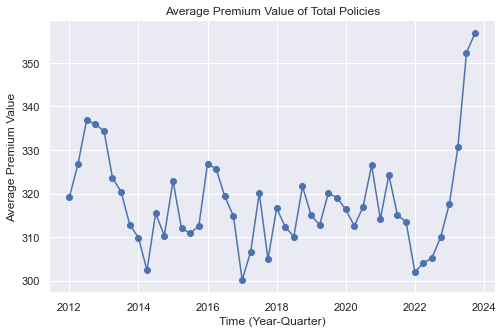

In [14]:
import pandas as pd
import matplotlib.pyplot as plt


# Create a Year-Quarter label
df_QTP['year_quarter'] = df_QTP['Year'].astype(str) + "-" + df_QTP['Quarter']

# If you want proper datetime for ordering:
df_QTP['period'] = pd.PeriodIndex(df_QTP['Year'].astype(str) + df_QTP['Quarter'], freq='Q').to_timestamp()

# Sort by time
df_QTP = df_QTP.sort_values('period')

# Plot using datetime (recommended)
plt.figure(figsize=(8,5))
plt.plot(df_QTP['period'], df_QTP['Average Premium (£)'], marker='o')
plt.title("Average Premium Value of Total Policies")
plt.xlabel("Time (Year-Quarter)")
plt.ylabel("Average Premium Value")
plt.grid(True)
plt.show()



2. Plotting total number of policies over time 


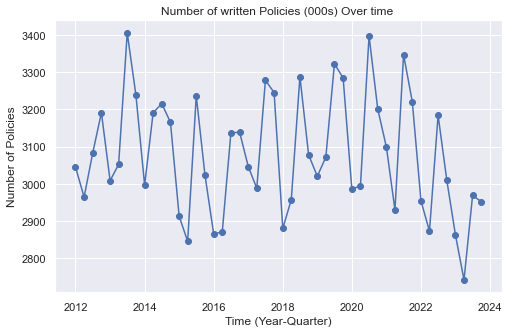

In [15]:
# Plot using datetime (recommended)
plt.figure(figsize=(8,5))
plt.plot(df_QTP['period'], df_QTP['Total Written Policies (000s)'], marker='o')
plt.title("Number of written Policies (000s) Over time ")
plt.xlabel("Time (Year-Quarter)")
plt.ylabel("Number of Policies")
plt.grid(True)
plt.show()


3. Plotting Total premium amount over time

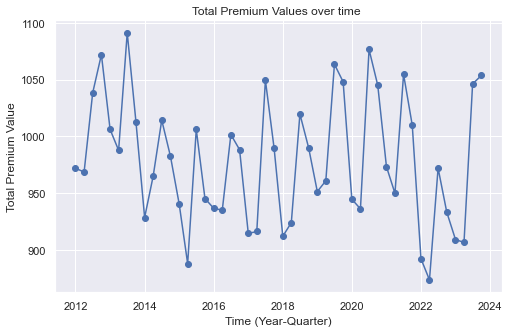

In [16]:
# Plot using datetime (recommended)
plt.figure(figsize=(8,5))
plt.plot(df_QTP['period'], df_QTP['Total  Written Premium (£m)'], marker='o')
plt.title("Total Premium Values over time ")
plt.xlabel("Time (Year-Quarter)")
plt.ylabel("Total Premium Value")
plt.grid(True)
plt.show()




### 📌 Key  Insights from Home Insurance Data Analysis (Policy Data)

#### 	Average Premium Trends:
From 2012 to around 2021, the average premium value remained relatively stable with moderate fluctuations between £300 and £330. After 2021, there is a steep upward trend, peaking sharply by 2024. This rise likely reflects insurers increasing premiums to offset higher claims costs, inflation in repair/rebuild expenses, and more frequent natural disaster events in the UK. Earlier dips (2014–2017) could be linked to competitive pricing and soft market conditions.

#### 	Policy Volume Patterns:
Policy volumes fluctuate cyclically, suggesting seasonal renewal and new business dynamics. There is a clear declining pattern after 2021, with the lowest values around 2023. This could indicate reduced new business acquisition due to affordability pressures from rising premiums or tighter underwriting standards. The earlier peaks (2013, 2020) likely represent strong market competition or increased consumer switching activity.

####  Total Premium Value Observations:
Despite the recent fall in policy numbers, total premium values remain relatively stable overall and even trend upward from 2022 to 2024. This implies that premium rate increases have offset the decline in policy count. The graph shows continuous ups and downs over the years, meaning premiums have been quite volatile. Only in the latest period (after 2023), there’s a slight upward movement, suggesting insurers may have started increasing rates again to recover from earlier low periods.



## Claim Trend 

1. Plotting Total Claims Incurred over time 

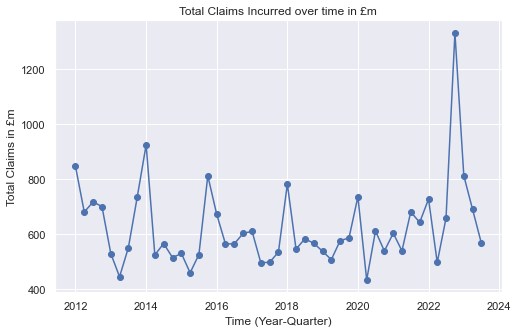

In [131]:

df_CI['year_quarter'] = df_CI['Year'].astype(str) + "-" + df_CI['Quarter']

# If you want proper datetime for ordering:
df_CI['period'] = pd.PeriodIndex(df_CI['Year'].astype(str) + df_CI['Quarter'], freq='Q').to_timestamp()

# Sort by time
df_CI = df_CI.sort_values('period')

# Plot using datetime (recommended)
plt.figure(figsize=(8,5))
plt.plot(df_CI['period'], df_CI['TOTAL'], marker='o')
plt.title("Total Claims Incurred over time in £m")
plt.xlabel("Time (Year-Quarter)")
plt.ylabel("Total Claims in £m")
plt.grid(True)
plt.show()

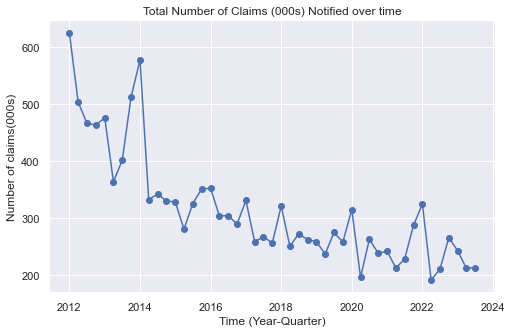

In [132]:
df_NC['year_quarter'] = df_NC['Year'].astype(str) + "-" + df_NC['Quarter']

# If you want proper datetime for ordering:
df_NC['period'] = pd.PeriodIndex(df_NC['Year'].astype(str) + df_NC['Quarter'], freq='Q').to_timestamp()

# Sort by time
df_NC = df_NC.sort_values('period')

# Plot using datetime (recommended)
plt.figure(figsize=(8,5))
plt.plot(df_NC['period'], df_NC['TOTAL'], marker='o')
plt.title("Total Number of Claims (000s) Notified over time")
plt.xlabel("Time (Year-Quarter)")
plt.ylabel("Number of claims(000s)")
plt.grid(True)
plt.show()

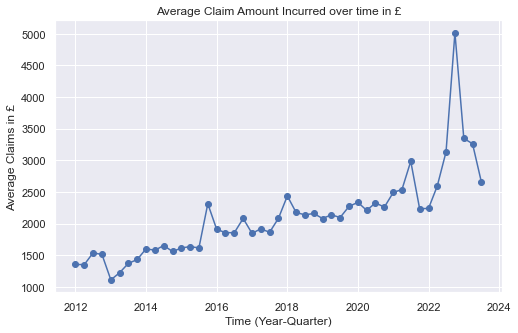

In [130]:
### Avg Claim 
df_CI["TOTAL"] = df_CI["TOTAL"].replace('[£,]', '', regex=True).astype(float)
df_temp = df_CI.copy()
df_temp["Avg Claim"] = df_CI["TOTAL"]* 1000 / df_NC["TOTAL"]


plt.figure(figsize=(8,5))
plt.plot(df_temp['period'], df_temp['Avg Claim'], marker='o')
plt.title("Average Claim Amount Incurred over time in £")
plt.xlabel("Time (Year-Quarter)")
plt.ylabel("Average Claims in £")
plt.grid(True)
plt.show()


### 📌 Insights from Claims Data Analysis

#### 1. **Total Claims Incurred Over Time**
- There are regular fluctuations in total claims, showing seasonal or cyclical patterns.
- A major spike occurred in late 2022, where claims exceeded 1200—significantly higher than other quarters.
- This peak could be due to a large-scale event (e.g., natural disaster) or increased claim severity.




Claims incurred during Q4 of 2022 was very high even though there was only a slight increase in number of claims . The rise in claim amount during Q4 2022 was mainly due to pipes+ peril - frozen /burst pipes claim. There was a significant weather-related event in the UK during Q4 of 2022 that aligns with the spike 

### ❄️ What Happened in Q4 2022?
- **December 2022 experienced a “deep freeze” across the UK**, with sub-zero temperatures lasting several days.
- According to Zurich Insurance, **burst pipe claims surged by 75%** compared to the previous year.
- Many households avoided turning on heating due to high energy costs, which **increased the risk of frozen pipes**.
- This led to **record numbers of water damage claims**, especially from pipes that froze, expanded, and burst.

### 🔍 How This Connects to Your Data
- The **sharp rise in total claims incurred** in Q4 2022 matches the timing of this cold snap.
- Although the **number of policies increased only slightly**, the **severity and frequency of claims spiked**, particularly those related to water damage.
- This event wasn’t a natural disaster in the traditional sense (like a flood or storm), but it was a **weather-driven insurance crisis** with substantial financial impact.

### 📊 Analyst Conclusion:
In December 2022, the UK experienced a severe deep freeze with temperatures dropping below −10°C insome regions. This prolonged cold spell led to widespread frozen and burst pipes, especially during freeze–thaw cycles. As a result, insurance claims for "Pipes+" and "Escape of Water (Non-weather)" rose sharply in Q4 2022, reflecting the direct impact of this
weather event on property damage.

- The Q4 2022 spike is a textbook example of how **extreme weather and economic behavior (like reduced heating)** can combine to drive up claims.
- It highlights the importance of **seasonal risk modeling** and **customer education on home protection during cold weather**.
- For future forecasting, this event should be treated as a **high-impact anomaly** and factored into winter risk assessments.



#### 2. **Claims(000s) Over Time**
- The number of claims  steadily declined from 2012 to 2024, except during two spikes: late 2013–early 2014 (February) and January 2022. The rate was also unusually high in early 2012.

- In 2012, the rate exceeded 600 claims per 1,000 policies, but by 2023–2024 it had dropped to below 100.

- This downward trend suggests improved risk management, stricter underwriting practices, or fewer claim-worthy incidents over time.( Claims Frequency Trend)

- A sudden increase in the number of policies occurred in Q1 2014, alongside a sharp rise in storm-related claims and incurred losses.

- This aligns with the severe UK weather in Q1 2014, when a series of powerful winter storms (including Cyclone Dirk and the 2013–14 storm sequence) struck the country, causing widespread damage, flooding, and strong winds.


### Enviromental Proofs: 

### Insights on Claims Spikes (2012–2014)

#### 2012 Q1 – Storm, Burst Pipes, Fire/Explosion, Other Domestic
In early January 2012, Cyclone Andrea struck the UK, bringing heavy winds and rain. This storm caused structural damage, power outages, and disruption. The cold winter and sharp freeze–thaw cycles likely contributed to frozen or burst pipes, while increased heating use and electrical faults after storm damage may explain the rise in fire and explosion claims. These conditions also explain the spike in other domestic damages.

#### 2012 Q2 – Flood and Other Domestic
From April to December 2012, the UK experienced exceptionally wet conditions, with record rainfall leading to widespread river, surface, and groundwater flooding. This period is often described as the year Britain’s weather “turned dangerous,” with hundreds of thousands of flood-related insurance claims. The spike in Q2 matches the start of this flooding season.

#### 2012 Q3 – 2013 Q1 – Other Domestic
Weather conditions were relatively mild during this period. There were no major storms or prolonged freezes, so the claims pattern shifted back to routine domestic damages, such as minor household accidents or wear-and-tear incidents.

#### 2013 Q4 – 2014 Q1 – Storm
Between mid-December 2013 and mid-February 2014, the UK faced its stormiest period in over 20 years, with a series of 6–12 major storms hitting in rapid succession. These storms caused severe coastal flooding, especially in Somerset and the South West, alongside strong winds, high waves, and river flooding. This explains the sharp spike in storm-related claims during Q1 2014, as well as increased policy activity, with households seeking protection after widespread damage.

#### Q1 2022 – Storm Malik, Corrie, and Dudley - Not an outlier ...
The UK was hit by multiple storms in early 2022, including Storm Malik (29 Jan), Storm Corrie (30–31 Jan), and Storm Dudley (16–17 Feb). These storms caused strong winds, power outages, and structural damage in Northern England and Scotland. While the number of claims did increase during this period, it did not rise in an abnormal or extreme way compared to earlier storm-driven spikes.





Find below the boxplots to find the outliers in each perils to find which peril is the main reason for each quarter. 

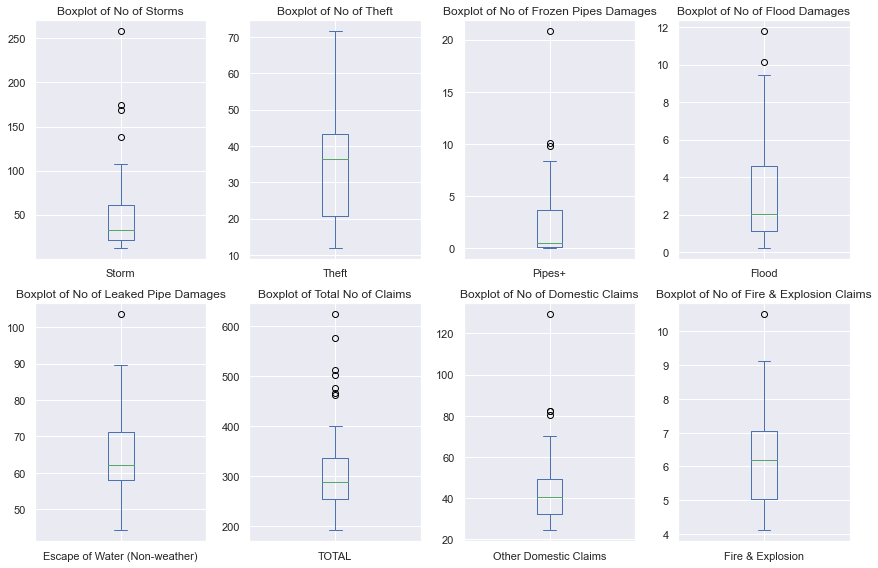

In [135]:
import matplotlib.pyplot as plt

# Columns and titles
cols = [
    ('Storm', "Boxplot of No of Storms"),
    ('Theft', "Boxplot of No of Theft"),
    ('Pipes+', "Boxplot of No of Frozen Pipes Damages"),
    ('Flood', "Boxplot of No of Flood Damages"),
    ('Escape of Water (Non-weather)', "Boxplot of No of Leaked Pipe Damages"),
    ('TOTAL', "Boxplot of Total No of Claims"),
    ('Other Domestic Claims', "Boxplot of No of Domestic Claims"),
    ('Fire & Explosion', "Boxplot of No of Fire & Explosion Claims")
]

# 2 rows × 4 cols
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(12, 8))  
axes = axes.flatten()

# Loop through each column
for i, (col, title) in enumerate(cols):
    df_NC[col].plot(kind='box', ax=axes[i])
    axes[i].set_title(title)

# Adjust spacing
plt.tight_layout()
plt.show()


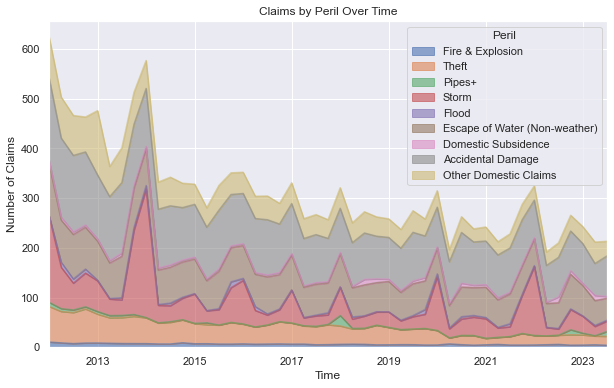

In [20]:
# area chart

quarter_to_month = {"Q1": 1, "Q2": 4, "Q3": 7, "Q4": 10}
df_NC["Month"] = df_NC["Quarter"].map(quarter_to_month)
df_NC["Date"] = pd.to_datetime(df_NC[["Year", "Month"]].assign(DAY=1))

# Set Date as index
df_NC = df_NC.set_index("Date")

# Plot area chart for selected columns
df_NC[["Fire & Explosion", "Theft", "Pipes+", "Storm", "Flood", "Escape of Water (Non-weather)", "Domestic Subsidence", "Accidental Damage", "Other Domestic Claims"]].plot.area(alpha=0.6, figsize=(10, 6))

plt.title("Claims by Peril Over Time")
plt.xlabel("Time")
plt.ylabel("Number of Claims")
plt.legend(title="Peril")
plt.show()

- "Other Domestic Claims" is consistently present in every quarter from 2012 to 2023.
- Even though it's not the highest in most individual quarters, its steady contribution adds up visually, creating a large   area in the chart.
- In contrast, perils like "Storm" or "Flood" have sharp spikes but only in specific quarters — so they appear narrower even if they had higher values during those periods.

So when I say the chart suggests dominance, I mean it visually implies that "Other Domestic Claims" is the largest contributor due to its persistent volume, not necessarily its peak impact.
Your detailed data analysis shows that perils like "Storm" and "Escape of Water" often drive the actual spikes — and that’s exactly why pairing visuals with raw data is so important in insurance analytics.


### Conclusion from Area Chart and Data
While the stacked area chart suggests "Other Domestic Claims" is the dominant peril over time, the actual data shows that storm, escape of water, and accidental damage are the key drivers of claim spikes in specific quarters. Perils like "Storm" in 2012 Q1 and 2014 Q1, and "Escape of Water" in multiple cold quarters, contributed more to total claims than "Other Domestic" in those periods. The chart reflects long-term consistency, but quarter-level analysis reveals sharper, event-driven impacts from weather-related perils.




Now our real question is does the rise in number of claims impacted the buisness? To check that we need to find the abnormalrises in total claim incurred column. 

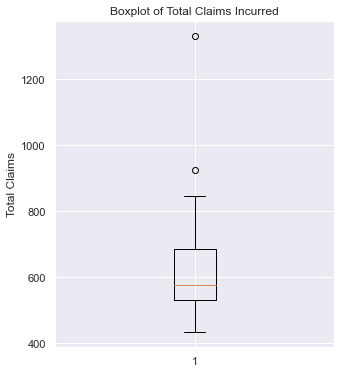

In [21]:
# Plotting Box plot of TOTAL from Claims incurred table

plt.figure(figsize=(5,6))
plt.boxplot(df_CI["TOTAL"], vert=True)
plt.title("Boxplot of Total Claims Incurred")
plt.ylabel("Total Claims")
plt.show()

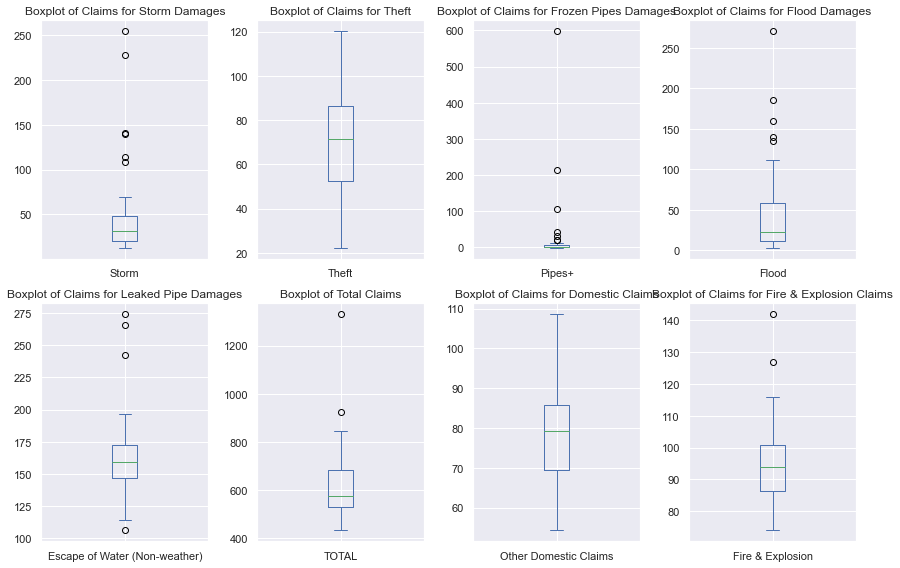

In [136]:
# Columns and titles
cols = [
    ('Storm', "Boxplot of Claims for Storm Damages"),
    ('Theft', "Boxplot of Claims for Theft"),
    ('Pipes+', "Boxplot of Claims for Frozen Pipes Damages"),
    ('Flood', "Boxplot of Claims for Flood Damages"),
    ('Escape of Water (Non-weather)', "Boxplot of Claims for Leaked Pipe Damages"),
    ('TOTAL', "Boxplot of Total Claims"),
    ('Other Domestic Claims', "Boxplot of Claims for Domestic Claims"),
    ('Fire & Explosion', "Boxplot of Claims for Fire & Explosion Claims")
]

# 2 rows × 4 cols
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(12, 8))  
axes = axes.flatten()

# Loop through each column
for i, (col, title) in enumerate(cols):
    df_CI[col].plot(kind='box', ax=axes[i])
    axes[i].set_title(title)

# Adjust spacing
plt.tight_layout()
plt.show()


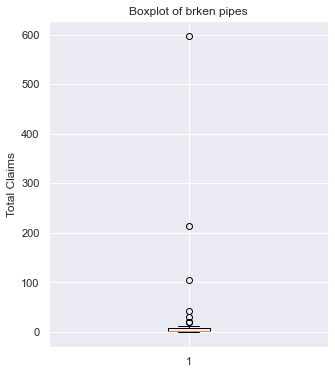

In [23]:
plt.figure(figsize=(5,6))
plt.boxplot(df_CI["Pipes+"], vert=True)
plt.title("Boxplot of brken pipes")
plt.ylabel("Total Claims")
plt.show()

### Comparison Table  to check whether the rise of number of claims increased the total claim incurred

Comparison tabless in folder - 2014 Q1 (Storm ) and 2022 Q4 (In December 2022, the UK experienced a severe deep 
                                                              freeze with temperatures dropping below −10°C in
                                                              some regions. This prolonged cold spell led to
                                                              widespread frozen and burst pipes, especially during 
                                                              freeze–thaw cycles. As a result, insurance 
                                                              claims for "Pipes+" and "Escape of Water (Non-weather)" rose 
                                                              sharply in Q4 2022, reflecting the direct impact of this
                                                              weather event on property damage.)
                                                              
### Conclusion:
Only in 2014 the abnormal increase in number of policies affected the total claim incurred and 

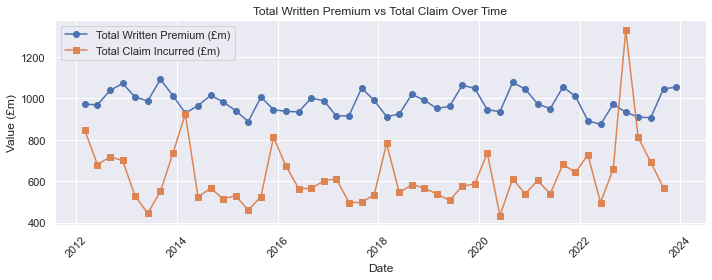

In [24]:
### Plotting Total Premium Vs Total Claims


def quarter_to_date(year, quarter_str):
    # Extract number from "Q1", "Q2", etc.
    quarter = int(quarter_str[1])
    month = (quarter - 1) * 3 + 3  # Q1 -> Mar, Q2 -> Jun, Q3 -> Sep, Q4 -> Dec
    return pd.Timestamp(year=int(year), month=month, day=1)

# Apply to both dataframes
df_QTP['Date'] = df_QTP.apply(lambda row: quarter_to_date(row['Year'], row['Quarter']), axis=1)
df_CI['Date'] = df_CI.apply(lambda row: quarter_to_date(row['Year'], row['Quarter']), axis=1)

# Plotting
plt.figure(figsize=(10,4))
plt.plot(df_QTP['Date'], df_QTP['Total  Written Premium (£m)'], label='Total Written Premium (£m)', marker='o')
plt.plot(df_CI['Date'], df_CI['TOTAL'], label='Total Claim Incurred (£m)', marker='s')

plt.xlabel('Date')
plt.ylabel('Value (£m)')
plt.title('Total Written Premium vs Total Claim Over Time')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

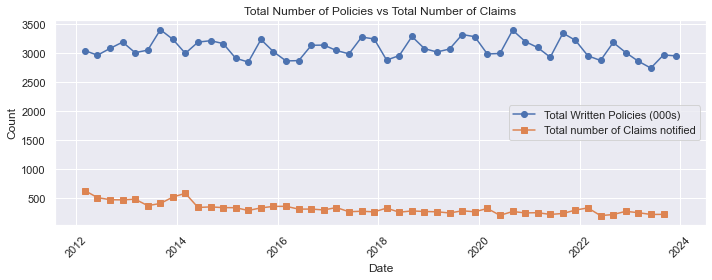

In [25]:
def quarter_to_date(year, quarter_str):
    # Extract number from "Q1", "Q2", etc.
    quarter = int(quarter_str[1])
    month = (quarter - 1) * 3 + 3  # Q1 -> Mar, Q2 -> Jun, Q3 -> Sep, Q4 -> Dec
    return pd.Timestamp(year=int(year), month=month, day=1)

# Apply to both dataframes
df_QTP['Date'] = df_QTP.apply(lambda row: quarter_to_date(row['Year'], row['Quarter']), axis=1)
df_NC['Date'] = df_NC.apply(lambda row: quarter_to_date(row['Year'], row['Quarter']), axis=1)


plt.figure(figsize=(10,4))
plt.plot(df_QTP['Date'], df_QTP['Total Written Policies (000s)'], label='Total Written Policies (000s)', marker='o')
plt.plot(df_NC['Date'], df_NC['TOTAL'], label='Total number of Claims notified', marker='s')

plt.xlabel('Date')
plt.ylabel('Count')
plt.title('Total Number of Policies vs Total Number of Claims')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 📊 Combined Conclusions of Premium and Claims Data

#### 1. Claims vs Premium (Top Graph)

- Seasonality & Volatility:
Claims incurred show noticeable fluctuations (peaks and troughs), while premiums are relatively stable with smaller oscillations. This suggests claims may be influenced by seasonal or external factors (e.g., weather events, economic conditions).

- Spike around 2022:
A sharp increase in claims incurred is visible around late 2022, while premiums did not rise proportionally. This could indicate a period of higher claim frequency/severity (e.g., natural disaster, inflationary pressures on repair/replacement costs).

- Gap between Premiums and Claims:
Premiums are consistently higher than claims incurred, suggesting overall underwriting profitability. But narrowing gaps or spikes in claims could indicate loss ratio pressure.

#### 2. Number of Policies vs Number of Claims (Bottom Graph)

- Policy Base Stability:
Written policies hover between 2800–3300 (000s), showing a strong and relatively stable customer base.

- Claims Frequency Decline:
Number of claims notified decreases gradually from 2012 to 2024, with fewer spikes compared to earlier years. This suggests possible improvements in risk management, policyholder behavior, or claim prevention strategies.

- Low Claims-to-Policy Ratio:
Even at peaks, claims are a small fraction of total policies, which indicates relatively low claim frequency compared to portfolio size.

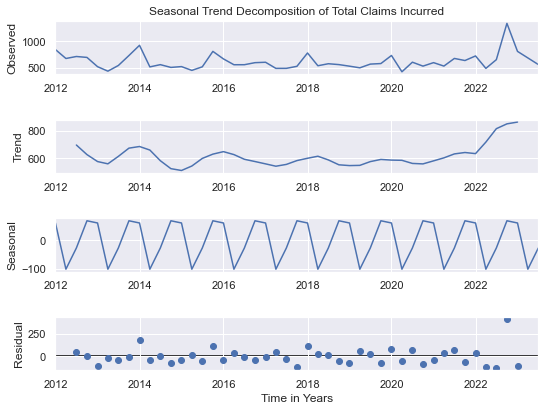

In [26]:
# checking whether Total Claims Incurred has any seasonality present

import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# Create PeriodIndex (quarterly)
df_CI['date'] = pd.PeriodIndex(year=df_CI['Year'],
                               quarter=df_CI['Quarter'].str[1:].astype(int),
                               freq='Q')

#  Convert PeriodIndex to datetime index and set as index
df_CI = df_CI.set_index(df_CI['date'].dt.to_timestamp())

# Run seasonal decomposition (quarterly data → period=4)
decomposition = seasonal_decompose(df_CI['TOTAL'], model='additive', period=4)

# Plot
fig = decomposition.plot()
fig.set_size_inches(8, 6)

fig.axes[0].set_title('Seasonal Trend Decomposition of Total Claims Incurred')
fig.axes[0].set_ylabel('Observed')
fig.axes[1].set_ylabel('Trend')
fig.axes[2].set_ylabel('Seasonal')
fig.axes[3].set_xlabel('Time in Years')
fig.axes[3].set_ylabel('Residual')

plt.show()


Observed(Top Plot)
Shows the raw claim data from 2012 to 2022. WE can see visible spikes, especially around 2021, indicating high-impact quarters.
- Trend (Second Plot):
Reveals a long-term upward trend, with a dip around 2016 and a sharp rise starting 2020. This could reflect increased policy uptake, inflation-adjusted claim costs, or more frequent severe events.
- Seasonal (Third Plot):
Displays a repeating yearly pattern, suggesting that certain quarters (likely winter or storm seasons) consistently see higher claims. This is useful for seasonal forecasting.
- Residual (Bottom Plot):
Captures the random noise or unexplained spikes not accounted for by trend or seasonality. Large residuals may point to unexpected events like natural disasters or economic shocks.


## Performance metrics


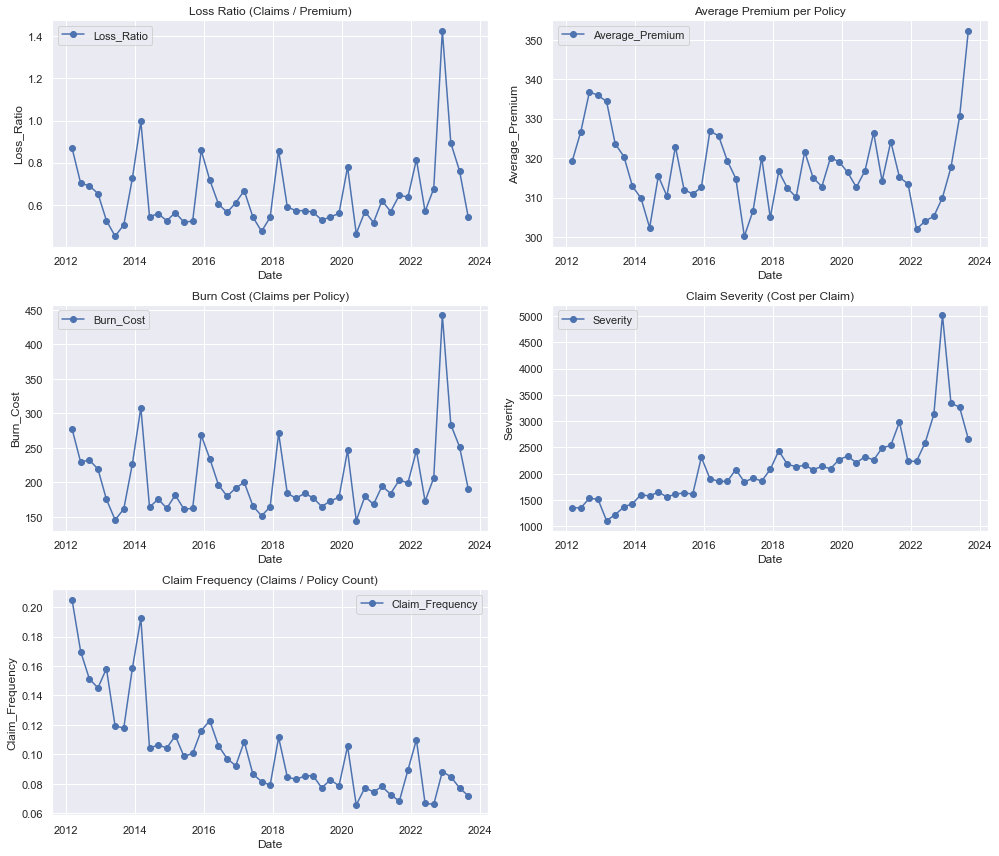

In [31]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Function to convert quarter to date ---
def quarter_to_date(year, quarter_str):
    quarter = int(quarter_str[1])  # e.g. "Q1" -> 1
    month = quarter * 3            # Q1->Mar(3), Q2->Jun(6), Q3->Sep(9), Q4->Dec(12)
    return pd.Timestamp(year=int(year), month=month, day=1)

# --- Merge dataframes by Year + Quarter ---
df_PM = df_CI.rename(columns={'TOTAL':'TOTAL_CI'}).merge(
    df_QTP, on=['Year','Quarter'], how='inner'
).merge(
    df_NC.rename(columns={'TOTAL':'TOTAL_NC'}), on=['Year','Quarter'], how='inner'
)

# --- Create Date column ---
df_PM['Date'] = df_PM.apply(lambda row: quarter_to_date(row['Year'], row['Quarter']), axis=1)

# --- KPIs ---
df_PM['Loss_Ratio'] = df_PM['TOTAL_CI'] / df_PM['Total  Written Premium (£m)']
df_PM['Average_Premium'] = df_PM['Average Premium (£)']
df_PM['Burn_Cost'] = df_PM['TOTAL_CI']*1000000 / (df_PM['Total Written Policies (000s)'] * 1000)
df_PM['Severity'] = df_PM['TOTAL_CI']*1000000 / (df_PM['TOTAL_NC'] * 1000)
df_PM['Claim_Frequency'] = df_PM['TOTAL_NC'] / df_PM['Total Written Policies (000s)']

# --- Plotting ---
metrics = ['Loss_Ratio','Average_Premium','Burn_Cost','Severity','Claim_Frequency']
titles = [
    'Loss Ratio (Claims / Premium)',
    'Average Premium per Policy',
    'Burn Cost (Claims per Policy)',
    'Claim Severity (Cost per Claim)',
    'Claim Frequency (Claims / Policy Count)'
]

fig, axs = plt.subplots(3, 2, figsize=(14,12))
axs = axs.flatten()

for i, metric in enumerate(metrics):
    axs[i].plot(df_PM['Date'], df_PM[metric], marker='o', label=metric)
    axs[i].set_title(titles[i])
    axs[i].set_xlabel('Date')
    axs[i].set_ylabel(metric)
    axs[i].legend()
    axs[i].grid(True)

# Hide any extra subplot (since you have 5 metrics but 6 subplots)
if len(metrics) < len(axs):
    for j in range(len(metrics), len(axs)):
        axs[j].axis('off')

plt.tight_layout()
plt.show()



### **1️⃣ Loss Ratio (Claims / Premium)**

**Meaning:**
Shows how much of the earned premium is paid out as claims.

* If ratio = 1 → company pays out as much as it earns.
* If ratio < 1 → profitable.
* If ratio > 1 → loss-making.

**Insights:**

* Mostly stable between **0.4–0.8**, meaning good profitability.
* Sharp spikes in **2013, 2016, 2018, 2021–2023**, especially **2023 (~1.4)** — indicates heavy claim costs or underpriced premiums in those periods.

---

### **2️⃣ Average Premium per Policy**

**Meaning:**
The **average price customers pay** for insurance per policy.
Higher values = company charging more premiums.

**Insights:**

* Fairly steady between **£310–£330** until 2022.
* **Big jump after 2022**, reaching **~£350+ in 2024**, showing insurers are **increasing prices sharply**, likely to offset rising claim costs and inflation.

Reason y sudden increase in avg premium price after 2022:  (Check in new busness avg premium data too to support)

###### 1. **Inflation and Increased Construction Costs**

Since 2022, inflation has led to higher costs for construction materials and labor. This has increased the expense of rebuilding homes, prompting insurers to raise premiums to maintain profitability. In 2023, the average premium for combined buildings and contents insurance rose by 13%, and by 19% in the second quarter of 2024 compared to the same period in 2023 ([abi.org.uk][1]).

##### 2. **Extreme Weather Events**

The UK experienced a record £573 million in weather-related home insurance claims in 2023, a significant increase from previous years. This surge was due to multiple storms causing widespread damage ([The Guardian][2]). Such events have led insurers to adjust premiums to account for the higher risk and increased claim payouts.

##### 3. **Increased Claims Volumes**

The frequency and severity of claims have risen, particularly due to climate-related events. For instance, claims for storm damage increased by 55% since 2023 ([GoCompare News][3]). This uptick in claims has pressured insurers to raise premiums to cover the higher payout costs.

##### 4. **Underwriting Losses**

In 2022, UK home insurers reported a net combined ratio of 122%, the worst in decades, indicating underwriting losses. Although this improved to 118% in 2023, it still reflected losses, prompting insurers to increase premiums to return to profitability ([Financial Times][4]).

##### 5. **Regional Variations**

Premium increases have varied across regions. For example, in the final quarter of 2024, premiums in Northern Ireland rose by 31% year-on-year, while London saw a 25% increase ([Insurance Business][5]).

These factors collectively explain the rise in home insurance premiums in the UK since 2022.





### **3️⃣ Burn Cost (Claims per Policy)**

**Meaning:**
Average **claim cost per policy sold** (not just per claim).
It combines how often and how severe claims are, overall portfolio impact.

**Insights:**

* Generally stable between **0.00015–0.00025**.---- values change by looking graph
* **Huge spike around 2023 (~0.43)** — insurers faced heavier claim payouts per policy, possibly due to costly weather events or inflationary pressures.

---

### **4️⃣ Claim Severity (Cost per Claim)**

**Meaning:**
Average **cost of each individual claim**.
Higher = claims are more expensive to settle.

**Insights:**

* Gradual rise from **~0.0012 to ~0.0025** over time. --- values change by looking graph
* **Massive jump in 2022 (~5)** — suggests **claims became much more expensive**, maybe from higher repair/replacement costs or large one-off events.
* Declines slightly afterward but remains elevated vs early years.

---

### **5️⃣ Claim Frequency (Claims / Policy Count)**

**Meaning:**
How **often claims happen** — number of claims per policy.
Shows trend in customer claim behaviour or risk exposure.

**Insights:**

* Clear **downward trend** from **0.20 (2012)** to **~0.08 (2024)** — fewer claims per policy now.
* This could reflect **better risk management, safer homes, or stricter claim approvals**.
* Occasional small spikes (e.g., 2013, 2021) but overall decline.

---

### 🧭 **Overall Picture**

* **Claim frequency ↓** → fewer claims filed.
* **Claim severity ↑** → but each claim costs more.
* **Average premium ↑ sharply** → insurers reacting to rising costs.
* **Loss ratio fluctuating** → some years highly unprofitable (esp. 2023).
* Suggests **inflation, catastrophic events, or costlier repairs** increased claim costs, and insurers are **adjusting pricing** to recover profitability.

---

## Conclusion

### **Insurance Portfolio Performance Summary (2012–2024)**

Overall, claim **frequency has steadily declined**, indicating fewer claims per policy — possibly due to improved risk management, safer customer behaviour, or stricter claim processes. However, **claim severity and burn cost have increased**, particularly around 2022–2023, showing that while fewer claims occur, each one has become significantly more expensive. The **average premium remained stable for most of the period** but rose sharply after 2022, suggesting insurers are adjusting pricing to counteract inflation and rising claim costs. Consequently, the **loss ratio fluctuated**, with notable spikes in 2013, 2018, and especially 2023, pointing to temporary periods of unprofitability.

In summary, the data reflects a shift from high-frequency, low-cost claims to **low-frequency, high-cost claims**, prompting insurers to raise premiums to maintain profitability.



# Comparison of Burn cost vs Average premium 
- From the line charts we can see that in 2022, burncost increased drastically and is high compared to avg premium 


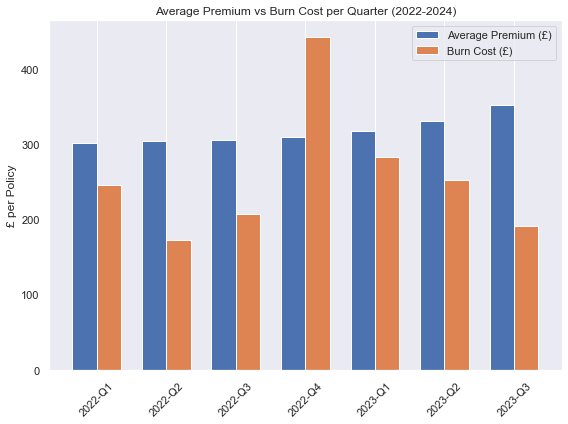

In [36]:
import matplotlib.pyplot as plt
import numpy as np

# Filter for years 2022 to 2024
df_plot = df_PM[(df_PM['Year'] >= 2022) & (df_PM['Year'] <= 2024)]

# Create labels like "2022-Q1", "2022-Q2", etc.
df_plot['Year_Quarter'] = df_plot['Year'].astype(str) + '-' + df_plot['Quarter']

labels = df_plot['Year_Quarter']
avg_premium = df_plot['Average_Premium']
burn_cost = df_plot['Burn_Cost']

x = np.arange(len(labels))  # the label locations
width = 0.35  # width of the bars

plt.figure(figsize=(8,6))
plt.bar(x - width/2, avg_premium, width, label='Average Premium (£)')
plt.bar(x + width/2, burn_cost, width, label='Burn Cost (£)')

plt.xticks(x, labels, rotation=45)
plt.ylabel('£ per Policy')
plt.title('Average Premium vs Burn Cost per Quarter (2022-2024)')
plt.legend()
plt.grid(axis='y')
plt.tight_layout()
plt.show()


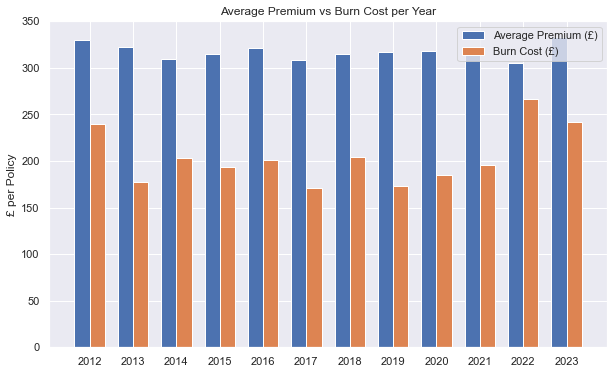

In [32]:
import matplotlib.pyplot as plt

years = df_PM['Year'].unique()
avg_premium = df_PM.groupby('Year')['Average_Premium'].mean()
burn_cost = df_PM.groupby('Year')['Burn_Cost'].mean()

x = range(len(years))
width = 0.35

plt.figure(figsize=(10,6))
plt.bar(x, avg_premium, width=width, label='Average Premium (£)')
plt.bar([i + width for i in x], burn_cost, width=width, label='Burn Cost (£)')

plt.xticks([i + width/2 for i in x], years)
plt.ylabel('£ per Policy')
plt.title('Average Premium vs Burn Cost per Year')
plt.legend()
plt.show()


### Insights:
- When comparing Burn Cost to Average Premium, a Burn Cost higher than the Average Premium indicates a negative margin per policy.

- In Q4 2022, a deep freeze in December caused an abnormal spike in Burn Cost, which exceeded the Average Premium for that quarter.

- However, when looking at the overall Burn Cost across the years, the Average Premium consistently remains higher than the Burn Cost. This indicates effective risk management and underwriting practices, even when accounting for expected natural disaster events.

## Macro and Market trends influencing the performance metrics

## 🧾 **1️⃣ Premium Trends**

### **Observation from Data:**

* Average premium remained **flat (≈£310–£330)** for most of 2012–2021.
* Then a **sharp increase from 2022–2024**, rising above **£350**.

### **Possible Market & Macro Drivers:**

* **FCA Pricing Reform (Jan 2022):**

  * Banned the “loyalty penalty” (charging renewals more than new business).
  * Resulted in *new business premiums rising* to align with renewal prices — explaining the **premium surge post-2022**.
* **High Inflation & Supply Chain Pressures (2021–2023):**

  * Construction materials (timber, steel, cement) and labour costs soared.
  * Insurers increased premiums to offset **rising rebuild and repair costs**.
* **Energy Crisis (2022):**

  * Higher heating/electrical system usage increased fire/fault risks — insurers priced this in.
* **Climate-related Risk Repricing:**

  * Frequent floods/storms in UK (Storm Eunice, Arwen, Babet) led to regional repricing — **premium hike justified**.

---

## 💸 **2️⃣ Claims Trends**

### **Claim Frequency (↓ steadily since 2012):**

* **Market Insight:**

  * **Improved home security** (smart alarms, better locks) and **stricter underwriting** have reduced petty theft and minor losses.
  * **COVID-19 lockdowns (2020)** also reduced break-ins and outdoor property damage.
  * **Cost-of-living pressure** may deter smaller, non-essential claim submissions (people avoid affecting no-claim bonuses).
    → So the **decline in claim frequency** matches **industry-wide behaviour changes and better risk control**.

---

### **Claim Severity (↑ sharply after 2020):**

* **Inflation Impact:**

  * UK inflation peaked around **10% (2022)** — drastically raising repair/replacement costs.
* **Labour Shortages & Material Costs:**

  * Brexit + global shortages increased rebuild expenses.
* **Weather-Driven Events:**

  * Floods, storms, and extreme cold events (2021–2023) led to costlier property damage — **explaining the spike in severity**.
    → The data’s **severity peak in 2022 (~5x normal)** fits exactly with **inflation + extreme weather** impacts.

---

## 💥 **3️⃣ Loss Ratio & Burn Cost (Profitability Indicators)**

### **Observation:**

* Loss ratio fairly stable (0.4–0.8) with a **major spike in 2023 (~1.4)**.
* Burn cost mirrors this, peaking in 2023.

### **Market Explanation:**

* The **2023 spike** could reflect:

  * **High inflation lag** hitting claim settlements from earlier events.
  * **Adverse weather losses** (multiple UK storms).
  * Premium adjustments not yet fully catching up to rising claim costs.
    → This indicates **temporary unprofitability**, aligning with **industry reports of poor underwriting results in 2022–23**.

---

## 📊 **4️⃣ Variability and Profitability Implications**

* High volatility suggests **catastrophic events** (e.g., storm seasons) or **macro shocks** can cause big swings year-to-year.
* Insurers now increasingly use **reinsurance** and **catastrophe modelling** to manage such volatility.
* Profitability needs to be viewed **over a cycle**, not per year, given this variability.

---

## 🌍 **Summary of Alignment**

| Metric                        | Data Trend                 | Market/Macro Explanation                                | Alignment |
| ----------------------------- | -------------------------- | ------------------------------------------------------- | --------- |
| **Avg Premium ↑ (post-2022)** | Sharp rise after 2022      | FCA pricing reform, inflation, cost of claims           | ✅ Strong  |
| **Claim Frequency ↓**         | Steady drop since 2012     | Better security, fewer small claims, behavioural change | ✅ Strong  |
| **Claim Severity ↑**          | Big jump post-2021         | Inflation, supply chain issues, weather events          | ✅ Strong  |
| **Loss Ratio spike (2023)**   | Short-term unprofitability | Inflation + claims surge before pricing caught up       | ✅ Strong  |
| **Burn Cost ↑ (2023)**        | Matches severity spike     | Combined inflation and catastrophe impact               | ✅ Strong  |

---

## 🧭 **Final Summary Paragraph (for report)**

The metrics align closely with real UK insurance market conditions. Claim frequency has steadily fallen due to improved home safety and cautious claim behaviour, while claim severity has escalated sharply since 2021 because of inflation, supply chain disruptions, and severe weather. These pressures caused temporary unprofitability in 2023, reflected in high loss ratios and burn costs. Insurers have since responded by raising premiums, supported by FCA pricing reforms, to restore margins. Overall, the data trends mirror industry-wide shifts toward lower-frequency but higher-cost claims, amplified by macroeconomic and climatic volatility.

---

Would you like me to make this section more **formal and concise (like for a presentation slide or executive report)** next?


## Volatality

In [89]:


# Metrics to analyze
metrics = ['Loss_Ratio', 'Burn_Cost', 'Severity', 'Claim_Frequency', 'Average_Premium']

# --- Yearly Coefficient of Variation (CV%) ---
variability = (
    df_PM.groupby('Year')[metrics]
    .agg(['mean', 'std'])
)

for m in metrics:
    variability[(m, 'CV')] = variability[(m, 'std')] / variability[(m, 'mean')] * 100

# Extract only CV columns
cv_table = variability.xs('CV', axis=1, level=1).round(2)

# --- Volatility of Yearly Changes ---
returns = df_PM.groupby('Year')[metrics].mean().pct_change()
volatility = returns.std() * 100
volatility = volatility.round(2).to_frame(name="Volatility (%)")

# --- Output ---
print("📊 Yearly Coefficient of Variation (CV %):")
print(cv_table)

print("\n📉 Average Volatility of Yearly Changes (based on % changes):")
print(volatility)


📊 Yearly Coefficient of Variation (CV %):
      Loss_Ratio  Burn_Cost  Severity  Claim_Frequency  Average_Premium
Year                                                                   
2012       13.23      10.81      6.95            16.10             2.53
2013       21.81      19.81     11.34            16.60             2.77
2014       34.74      34.89      2.56            34.54             1.74
2015       26.60      26.29     19.28             8.11             1.77
2016       10.56      11.74      5.55            12.90             1.75
2017       14.54      12.17      5.66            15.16             2.78
2018       21.62      22.00      6.29            14.96             1.61
2019        3.10       3.57      4.05             4.74             1.09
2020       23.83      23.58      2.63            21.41             1.86
2021        5.64       4.30     12.17            11.84             1.59
2022       44.00      45.20     38.09            25.22             1.11
2023       24.17      

#### Insights
A low CV% (e.g., <10–15%) means the metric is stable across years.
CV <10% = low, 10–25% = moderate, >25% = high volatility.

A high CV% (e.g., >20–30%) means the metric fluctuates a lot in its yearly level

| Concept                    | Simple Meaning                             | Why We Use It                        |
| -------------------------- | ------------------------------------------ | ------------------------------------ |
| **Rolling Mean**           | Average of the last few quarters           | Smooths the trend (removes noise)    |
| **Standard Deviation (σ)** | How much values fluctuate around the mean  | Quantifies volatility                |
| **±2σ Band**               | The “normal” range (covers ~95% of values) | Detects abnormal quarters (outliers) |



In that context:

✅ “sigma value” means the number of standard deviations from the mean (e.g., 2σ or 3σ).

✅ “window” means how many time points (quarters or years) we use to calculate rolling mean and std.

Adjusting these affects sensitivity:

Smaller window → catches short-term shocks.

Larger window → smoother trend, fewer false outliers.

Lower sigma (e.g., 1.5) → more outliers detected.

Higher sigma (e.g., 3) → only major anomalies flagged.



=== OUTLIER QUARTERS (beyond rolling mean ± 2σ) ===
Empty DataFrame
Columns: [Metric, Year, Quarter, YQ, Value]
Index: []


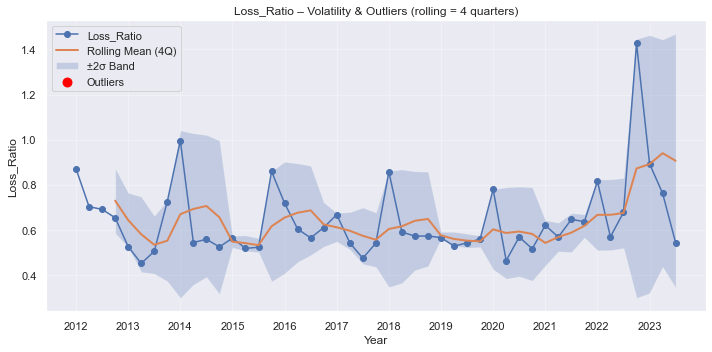

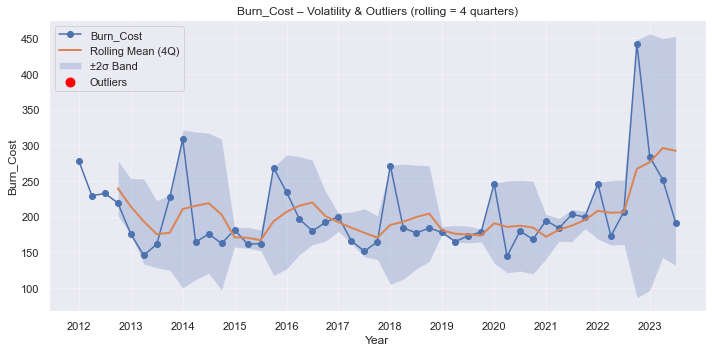

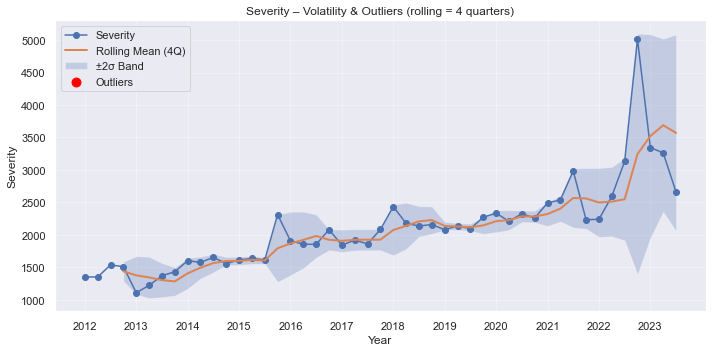

In [108]:
# Visualise + flag outliers (the “cat”/exceptional quarters)

# Make a 4-quarter rolling mean and rolling σ for LR and Burn Cost.

# Flag any quarter where the metric is outside rolling mean ± 2σ (or top/bottom 5% by percentile).
# These are your exceptional/catastrophe or pricing-lag quarters.

# STEP 3 — Volatility bands + outliers (rolling mean ± 2σ) and plots - To detect quarters where your profitability metrics (Loss Ratio, Burn Cost, Severity) behave abnormally — 
#i.e., jump far above or below normal levels — and visualise those spikes.



# Sigma =1.5
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------- A) Prep: clean quarter, sort, add YQ label ----------
def _to_quarter_int(q):
    if pd.isna(q): 
        return np.nan
    if isinstance(q, (int, float)): 
        return int(q)
    s = str(q).strip().upper()
    return int(s.replace("Q","")) if "Q" in s else int(s)

df_bands = df_PM.copy()
df_bands['Year'] = df_bands['Year'].astype(int)
df_bands['Quarter'] = df_bands['Quarter'].apply(_to_quarter_int).astype(int)
df_bands = df_bands.sort_values(['Year','Quarter']).reset_index(drop=True)
df_bands['YQ'] = df_bands['Year'].astype(str) + '-Q' + df_bands['Quarter'].astype(str)

# ---------- B) Helper: add rolling bands + outlier flag for a metric ----------
def add_rolling_bands_flag(data, metric, window=4, sigma=2.0):
    out = data.copy()
    mean_col = f'{metric}_mean_roll'
    std_col  = f'{metric}_std_roll'
    up_col   = f'{metric}_upper'
    lo_col   = f'{metric}_lower'
    flg_col  = f'{metric}_outlier'

    out[mean_col] = out[metric].rolling(window=window, min_periods=window).mean()
    out[std_col]  = out[metric].rolling(window=window, min_periods=window).std()
    out[up_col]   = out[mean_col] + sigma * out[std_col]
    out[lo_col]   = out[mean_col] - sigma * out[std_col]
    out[flg_col]  = (out[metric] > out[up_col]) | (out[metric] < out[lo_col])
    out[flg_col]  = out[flg_col].fillna(False)
    return out

# ---------- C) Configure which metrics to monitor ----------
monitor_metrics = ['Loss_Ratio', 'Burn_Cost', 'Severity']
window = 4   # 4 quarters = 1 year rolling
sigma  = 1.5 # ±2σ band

# ---------- D) Apply rolling bands + flags ----------
for m in monitor_metrics:
    df_bands = add_rolling_bands_flag(df_bands, m, window=window, sigma=sigma)

# ---------- E) Collect outlier quarters ----------
outlier_rows = []
for m in monitor_metrics:
    flg = f'{m}_outlier'
    if flg in df_bands:
        sub = df_bands[df_bands[flg]].copy()
        if not sub.empty:
            sub['Metric'] = m
            sub['Value']  = sub[m]
            outlier_rows.append(sub[['Metric','Year','Quarter','YQ','Value']])

outliers_table = (
    pd.concat(outlier_rows, ignore_index=True)
    if outlier_rows else
    pd.DataFrame(columns=['Metric','Year','Quarter','YQ','Value'])
).sort_values(['Metric','Year','Quarter'])

print("\n=== OUTLIER QUARTERS (beyond rolling mean ± 2σ) ===")
print(outliers_table)

# ---------- F) Plot helper ----------
def plot_metric_with_bands(data, metric, window=4):
    mean_col = f'{metric}_mean_roll'
    up_col   = f'{metric}_upper'
    lo_col   = f'{metric}_lower'
    flg_col  = f'{metric}_outlier'

    x = np.arange(len(data))
    plt.figure(figsize=(10,5))
    plt.plot(x, data[metric], marker='o', label=metric, linewidth=1.5)
    plt.plot(x, data[mean_col], label=f'Rolling Mean ({window}Q)', linewidth=2)
    plt.fill_between(x, data[lo_col], data[up_col], alpha=0.25, label=f'±2σ Band')

    # Highlight outliers
    out_idx  = x[data[flg_col].values]
    out_vals = data.loc[data[flg_col], metric]
    plt.scatter(out_idx, out_vals, color='red', s=80, label='Outliers', zorder=5)

    # ✅ Clean x-axis: show only year labels, not each quarter
    year_start_idx = data.groupby('Year').head(1).index
    year_labels = data['Year'].unique()
    plt.xticks(ticks=year_start_idx, labels=year_labels)

    plt.title(f'{metric} – Volatility & Outliers (rolling = {window} quarters)')
    plt.xlabel("Year")
    plt.ylabel(metric)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

# ---------- G) Generate the plots ----------
for m in monitor_metrics:
    plot_metric_with_bands(df_bands, m, window=window)



=== OUTLIER QUARTERS (beyond rolling mean ± σ) ===
        Metric  Year  Quarter       YQ        Value
14   Burn_Cost  2013        1  2013-Q1   175.546361
15   Burn_Cost  2013        2  2013-Q2   145.734309
16   Burn_Cost  2013        4  2013-Q4   226.859289
17   Burn_Cost  2014        1  2014-Q1    308.51158
18   Burn_Cost  2015        1  2015-Q1   181.703064
19   Burn_Cost  2015        4  2015-Q4   268.450478
20   Burn_Cost  2016        3  2016-Q3   179.986918
21   Burn_Cost  2017        2  2017-Q2   166.104414
22   Burn_Cost  2017        3  2017-Q3   151.563287
23   Burn_Cost  2018        1  2018-Q1   271.458225
24   Burn_Cost  2019        2  2019-Q2   165.001459
25   Burn_Cost  2020        1  2020-Q1   246.334146
26   Burn_Cost  2021        1  2021-Q1   194.616002
27   Burn_Cost  2021        3  2021-Q3    203.43511
28   Burn_Cost  2022        1  2022-Q1   246.097341
29   Burn_Cost  2022        2  2022-Q2   172.842779
30   Burn_Cost  2022        4  2022-Q4   442.357573
0   Loss_Rat

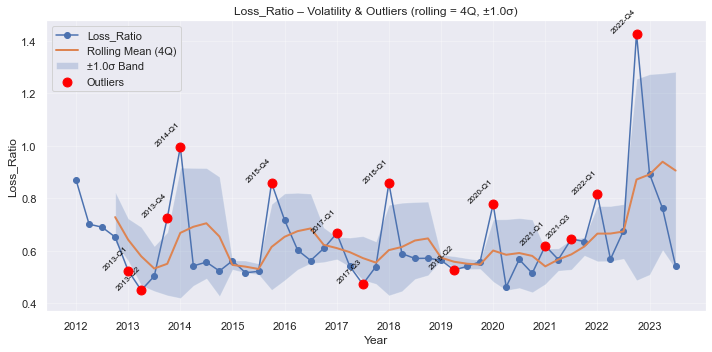

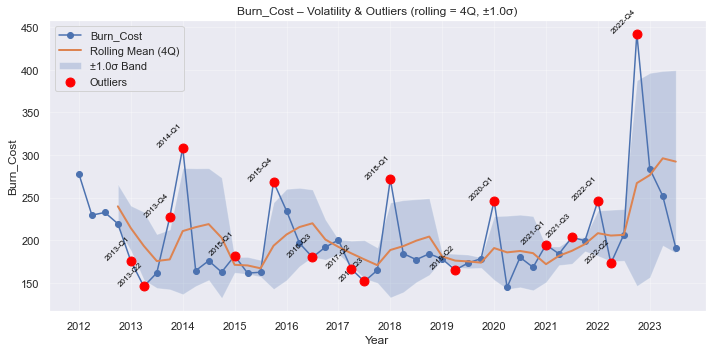

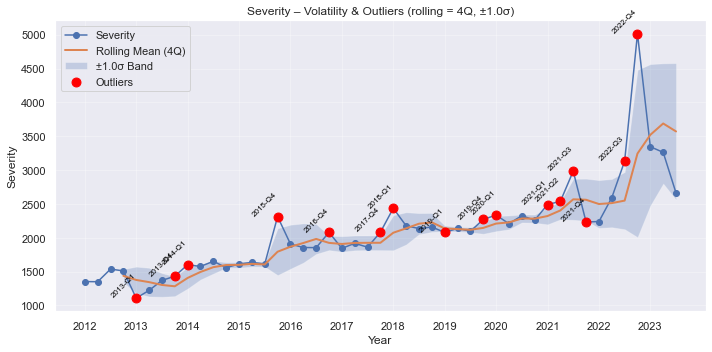

In [107]:
# When std dev sigma = 1


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------- A) Prep: clean quarter, sort, add YQ label ----------
def _to_quarter_int(q):
    if pd.isna(q): 
        return np.nan
    if isinstance(q, (int, float)): 
        return int(q)
    s = str(q).strip().upper()
    return int(s.replace("Q","")) if "Q" in s else int(s)

df_bands = df_PM.copy()
df_bands['Year'] = df_bands['Year'].astype(int)
df_bands['Quarter'] = df_bands['Quarter'].apply(_to_quarter_int).astype(int)
df_bands = df_bands.sort_values(['Year','Quarter']).reset_index(drop=True)
df_bands['YQ'] = df_bands['Year'].astype(str) + '-Q' + df_bands['Quarter'].astype(str)

# ---------- B) Helper: add rolling bands + outlier flag ----------
def add_rolling_bands_flag(data, metric, window=4, sigma=1.0):
    out = data.copy()
    mean_col = f'{metric}_mean_roll'
    std_col  = f'{metric}_std_roll'
    up_col   = f'{metric}_upper'
    lo_col   = f'{metric}_lower'
    flg_col  = f'{metric}_outlier'

    out[mean_col] = out[metric].rolling(window=window, min_periods=window).mean()
    out[std_col]  = out[metric].rolling(window=window, min_periods=window).std()
    out[up_col]   = out[mean_col] + sigma * out[std_col]
    out[lo_col]   = out[mean_col] - sigma * out[std_col]
    out[flg_col]  = (out[metric] > out[up_col]) | (out[metric] < out[lo_col])
    out[flg_col]  = out[flg_col].fillna(False)
    return out

# ---------- C) Configure which metrics to monitor ----------
monitor_metrics = ['Loss_Ratio', 'Burn_Cost', 'Severity']
window = 4   # 4 quarters = 1-year rolling
sigma  = 1.0 # narrower band → more sensitive

# ---------- D) Apply rolling bands + flags ----------
for m in monitor_metrics:
    df_bands = add_rolling_bands_flag(df_bands, m, window=window, sigma=sigma)

# ---------- E) Collect outlier quarters ----------
outlier_rows = []
for m in monitor_metrics:
    flg = f'{m}_outlier'
    if flg in df_bands:
        sub = df_bands[df_bands[flg]].copy()
        if not sub.empty:
            sub['Metric'] = m
            sub['Value']  = sub[m]
            outlier_rows.append(sub[['Metric','Year','Quarter','YQ','Value']])

outliers_table = (
    pd.concat(outlier_rows, ignore_index=True)
    if outlier_rows else
    pd.DataFrame(columns=['Metric','Year','Quarter','YQ','Value'])
).sort_values(['Metric','Year','Quarter'])

print("\n=== OUTLIER QUARTERS (beyond rolling mean ± σ) ===")
print(outliers_table)

# ---------- F) Plot helper ----------
def plot_metric_with_bands(data, metric, window=4):
    mean_col = f'{metric}_mean_roll'
    up_col   = f'{metric}_upper'
    lo_col   = f'{metric}_lower'
    flg_col  = f'{metric}_outlier'

    x = np.arange(len(data))
    plt.figure(figsize=(10,5))
    plt.plot(x, data[metric], marker='o', label=metric, linewidth=1.5)
    plt.plot(x, data[mean_col], label=f'Rolling Mean ({window}Q)', linewidth=2)
    plt.fill_between(x, data[lo_col], data[up_col], alpha=0.25, label=f'±{sigma}σ Band')

    # Highlight & annotate outliers
    out_idx  = x[data[flg_col].values]
    out_vals = data.loc[data[flg_col], metric]
    plt.scatter(out_idx, out_vals, color='red', s=80, label='Outliers', zorder=5)
    for idx in out_idx:
        plt.text(idx, data.loc[idx, metric], data.loc[idx, 'YQ'],
                 fontsize=8, color='black', rotation=45,
                 ha='right', va='bottom')

    # ✅ Clean x-axis: quarterly points, yearly labels
    year_start_idx = data.groupby('Year').head(1).index
    year_labels = data['Year'].unique()
    plt.xticks(ticks=year_start_idx, labels=year_labels)

    plt.title(f'{metric} – Volatility & Outliers (rolling = {window}Q, ±{sigma}σ)')
    plt.xlabel("Year")
    plt.ylabel(metric)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

# ---------- G) Generate plots ----------
for m in monitor_metrics:
    plot_metric_with_bands(df_bands, m, window=window)


A 4-quarter rolling analysis using ±2σ control bands shows no statistically extreme outliers, indicating relatively stable quarter-to-quarter performance.
However, modest peaks can still be observed visually around [years], reflecting mild volatility likely due to [weather/inflation effects].
To capture subtler variation, tighter (±1.5σ) bands or percentile thresholds may be used.

## Insights
Exactly — if you used σ = 1.5 and window = 4, and still got no outliers, that simply means your data is relatively stable over time (i.e., no quarter deviates enough from the rolling mean ± 1.5×std).

But that doesn’t necessarily mean there’s no volatility — just that the chosen sensitivity isn’t enough to highlight the small fluctuations.



Step 3 – Outlier Quarters (σ = 1)

Using a 4-quarter rolling mean ± 1σ, several quarters across Burn Cost, Loss Ratio, and Severity were flagged as abnormal, indicating unusual claims activity:

Burn Cost: High values in 2014-Q1, 2018-Q1, 2022-Q4 indicate unexpectedly high claims, while low values in 2013-Q2 reflect low claim activity.

Loss Ratio: Spikes in 2014-Q1, 2020-Q1, and 2022-Q4 highlight periods of abnormal profitability or loss, where claims significantly exceeded (or were much lower than) premiums collected.

Severity: Exceptional quarters such as 2021-Q3 and 2022-Q4 indicate large claims per event, likely driven by catastrophic events or high-cost claims.

Overall Insight:
the market is mostly stable,

but there are a few mildly exceptional quarters (not major catastrophes)

In [120]:
# Step 4 
#Step 4 — Create an “underlying” profitability view (normalised) Build three views of profitability (do all three if you can): 
#Reported LR: the raw LR as observed. Underlying LR (exclude outliers): recompute LR after removing flagged quarters. 
#Underlying LR (winsorised): cap extreme quarters at the 95th percentile and recompute LR.


# STEP 4 — Create an “Underlying” Profitability View (Normalised)
# Uses df_PM which already contains: Loss_Ratio, Burn_Cost, Severity

import pandas as pd
import numpy as np

# --- 1️⃣ Reported (raw, as observed) ---
reported = {
    'Loss_Ratio': df_PM['Loss_Ratio'].mean(),
    'Burn_Cost': df_PM['Burn_Cost'].mean(),
    'Severity': df_PM['Severity'].mean()
}

# --- 2️⃣ Underlying (exclude outliers) ---
# If your Step 3 code created flags (e.g. Loss_Ratio_outlier etc. in df_bands), we’ll use those
# If not, fall back to df_PM (no exclusion)
try:
    df_stable = df_bands.copy()  # use your volatility output dataframe
    # Drop all quarters flagged as outliers in any key metric
    mask_outlier = (
        df_stable.get('Loss_Ratio_outlier', False) |
        df_stable.get('Burn_Cost_outlier', False) |
        df_stable.get('Severity_outlier', False)
    )
    df_underlying = df_stable[~mask_outlier]
except:
    df_underlying = df_PM.copy()  # fallback if df_bands not available

underlying = {
    'Loss_Ratio': df_underlying['Loss_Ratio'].mean(),
    'Burn_Cost': df_underlying['Burn_Cost'].mean(),
    'Severity': df_underlying['Severity'].mean()
}

# --- 3️⃣ Underlying (winsorised at 95th percentile) ---
LR_cap = df_PM['Loss_Ratio'].quantile(0.95)
BC_cap = df_PM['Burn_Cost'].quantile(0.95)
SV_cap = df_PM['Severity'].quantile(0.95)

winsorised = {
    'Loss_Ratio': df_PM['Loss_Ratio'].clip(upper=LR_cap).mean(),
    'Burn_Cost': df_PM['Burn_Cost'].clip(upper=BC_cap).mean(),
    'Severity': df_PM['Severity'].clip(upper=SV_cap).mean()
}

# --- 4️⃣ Combine results ---
summary = pd.DataFrame({
    'Metric': ['Loss_Ratio', 'Burn_Cost', 'Severity'],
    'Reported_Mean': [reported['Loss_Ratio'], reported['Burn_Cost'], reported['Severity']],
    'Underlying_Excl_Outliers': [underlying['Loss_Ratio'], underlying['Burn_Cost'], underlying['Severity']],
    'Underlying_Winsorised': [winsorised['Loss_Ratio'], winsorised['Burn_Cost'], winsorised['Severity']]
})

print("\n=== Profitability Views (Reported vs Underlying) ===")
print(summary.round(3))



=== Profitability Views (Reported vs Underlying) ===
       Metric  Reported_Mean  Underlying_Excl_Outliers  Underlying_Winsorised
0  Loss_Ratio          0.642                     0.642                  0.628
1   Burn_Cost        203.518                   203.518                199.498
2    Severity       2105.914                  2105.914               2064.355


## Insights 

nterpretation:

The Reported and Underlying (Excl. Outliers) values are nearly identical, indicating that extreme values have minimal influence on the overall averages. This suggests a stable distribution with limited volatility in typical quarters.

The Winsorised values (where extreme values are capped) show only a modest reduction—particularly for Burn Cost and Severity. This indicates that a few high-severity or high-cost claim periods exist, but they don’t dominate profitability trends.

The Loss Ratio remains almost unchanged, reinforcing that profitability (claims vs premium) is not heavily distorted by outliers in this dataset.

Overall, the similarity between reported and adjusted figures implies that the observed performance trends reflect genuine market behavior rather than being driven by anomalies.

Business implication:
Profitability metrics appear reliable and representative of the underlying portfolio. Outlier treatment confirms that occasional spikes in claim costs or severities exist, but they don’t materially distort the overall market view — suggesting a mature and stable risk profile in the UK Home Insurance dataset.


# Conclusion

When looking at profitability, raw (reported) metrics can be distorted by one-off events — for example, a severe storm in winter or an unusually large claim.
To get a clearer picture of underlying performance, I checked the variability of key metrics such as Loss Ratio, Burn Cost, and Claim Severity.
After removing extreme outliers and re-calculating, the averages hardly changed, suggesting the portfolio is stable with no major volatility-driven distortion.
This means that the overall profitability trends we observe likely reflect genuine market behaviour rather than data anomalies.




Going forward, profitability could be maintained by factoring seasonal and peril-based variability into pricing — for example, applying higher technical rates for weather-sensitive regions or quarters, and monitoring claim severity trends to adjust reserves early.







Profitability Variability & Market Response

Although we analysed volatility across key metrics (Loss Ratio, Burn Cost, Claim Severity), the results showed limited quarter-to-quarter variation once outliers were removed.
This suggests that insurers have been effectively managing profitability through proactive pricing and underwriting strategies.

Following periods of increased claims from weather-related or catastrophic events, average premiums were adjusted upward to offset higher expected losses.
As a result, profitability metrics remained relatively stable — reflecting accurate risk assessment and disciplined underwriting rather than random fluctuations.

In short:

The market shows resilience to shocks through dynamic pricing.

Loss Ratios remained stable, indicating that higher premiums successfully compensated for elevated claims.

Low volatility in the underlying data implies strong portfolio control and responsive pricing actions.

💬 How to say it during the presentation:

“Even though there were some claim spikes due to events like severe weather, insurers appear to have priced in that risk quite well. We can see that from the stable loss ratio and burn cost after removing outliers. This suggests that accurate underwriting and premium adjustments have helped maintain overall profitability despite natural-disaster-driven volatility.”

In [121]:
#step 5 

df_PM.groupby('Year')[['Loss_Ratio','Burn_Cost','Severity']].agg(['mean','std'])


Loss_Ratio             Burn_Cost                 Severity             
           mean       std        mean         std         mean          std
Year                                                                       
2012   0.728852  0.096440  239.728698   25.924770  1438.177426    99.943673
2013   0.551162  0.120201  177.415875   35.139883  1283.644960   145.573361
2014   0.654986  0.227532  202.777463   70.739394  1597.728881    40.904383
2015   0.615230  0.163677  193.465287   50.859955  1794.197985   346.004842
2016   0.623405  0.065821  200.687901   23.557028  1924.927953   106.770920
2017   0.555611  0.080782  170.656486   20.767959  1926.516242   109.031554
2018   0.647697  0.140026  204.233826   44.937120  2227.437825   140.109968
2019   0.548165  0.017006  173.639639    6.202112  2146.075189    86.850899
2020   0.581101  0.138487  184.769198   43.574451  2282.453091    59.993974
2021   0.617096  0.034824  195.334994    8.397954  2561.666351   311.783200
2022   0.871841  0.383580  266.987513  120.685015  3244.519325  1235.775669
2023   0.732374  0.176982  242.189999   46.974188  3089.524883   373.114241

## Analysis of New Buisness Data and Renewal for Premium

### Customer Base - Policy Count 

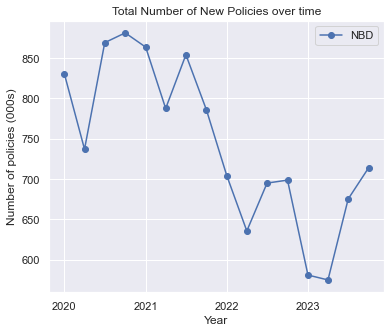

In [50]:
# New Buisness Data - Customer base ( no of policies)


import matplotlib.dates as mdates


# Ensure period column is datetime (from your Year and Quarter)
df_NBD['period'] = pd.PeriodIndex(df_NBD['Year'].astype(str) + df_NBD['Quarter'], freq='Q').to_timestamp()
df_NBD = df_NBD.sort_values('period')

plt.figure(figsize=(6,5))

# Plot quarterly points
plt.plot(df_NBD['period'], df_NBD['Number of policies (000s)'], marker='o', label='NBD')

plt.title("Total Number of New Policies over time")
plt.xlabel("Year")
plt.ylabel("Number of policies (000s)")
plt.grid(True)

# Set x-axis ticks to be at the start of each year
years = pd.to_datetime(df_NBD['Year'].unique().astype(str))
plt.xticks(years, [year.year for year in years])

plt.legend()
plt.show()


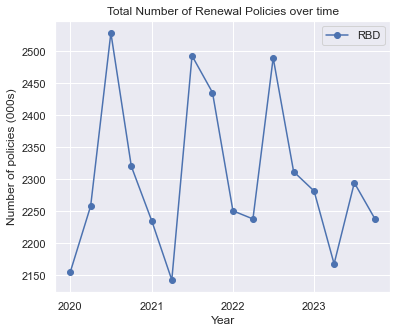

In [49]:
# Renewal Buisness Data - Customer base trend

# Ensure period column is datetime from Year and Quarter
df_RBD['period'] = pd.PeriodIndex(df_RBD['Year'].astype(str) + df_RBD['Quarter'], freq='Q').to_timestamp()
df_RBD = df_RBD.sort_values('period')

plt.figure(figsize=(6,5))

# Plot quarterly points
plt.plot(df_RBD['period'], df_RBD['Number of policies (000s)'], marker='o', label='RBD')

plt.title("Total Number of Renewal Policies over time")
plt.xlabel("Year")
plt.ylabel("Number of policies (000s)")
plt.grid(True)

# Set x-axis ticks at the start of each year
years = pd.to_datetime(df_RBD['Year'].unique().astype(str))
plt.xticks(years, [year.year for year in years])

plt.legend()
plt.show()



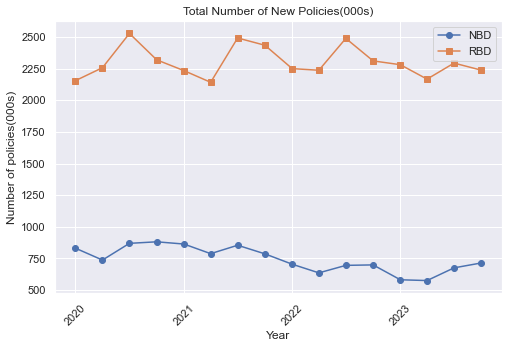

In [51]:


import matplotlib.dates as mdates

# Make sure both dataframes have the 'period' column
df_NBD['period'] = pd.PeriodIndex(df_NBD['Year'].astype(str) + df_NBD['Quarter'], freq='Q').to_timestamp()
df_RBD['period'] = pd.PeriodIndex(df_RBD['Year'].astype(str) + df_RBD['Quarter'], freq='Q').to_timestamp()

# Sort by period
df_NBD = df_NBD.sort_values('period')
df_RBD = df_RBD.sort_values('period')

plt.figure(figsize=(8,5))

# Plot first dataset
plt.plot(df_NBD['period'], df_NBD['Number of policies (000s)'], marker='o', label='NBD')

# Plot second dataset
plt.plot(df_RBD['period'], df_RBD['Number of policies (000s)'], marker='s', label='RBD')

plt.title("Total Number of New Policies(000s)")
plt.xlabel("Year")
plt.ylabel("Number of policies(000s)")
plt.grid(True)

# X-axis formatting: show only year
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)

# Show legend
plt.legend()

plt.show()


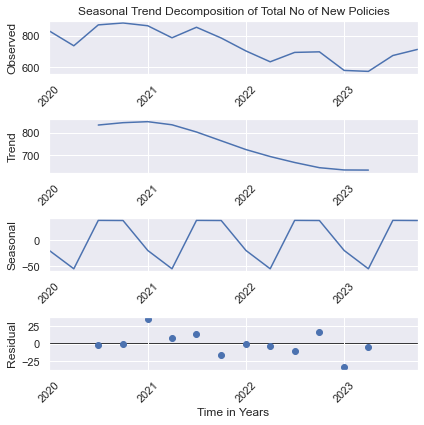

In [56]:
# Seasonal decomposition of New Business policies

import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
import pandas as pd

# Create PeriodIndex (quarterly)
df_NBD['date'] = pd.PeriodIndex(year=df_NBD['Year'],
                               quarter=df_NBD['Quarter'].str[1:].astype(int),
                               freq='Q')

# Convert PeriodIndex to datetime and set as index
df_NBD = df_NBD.set_index(df_NBD['date'].dt.to_timestamp())

# Run seasonal decomposition (quarterly data → period=4)
decomposition = seasonal_decompose(df_NBD['Number of policies (000s)'], model='additive', period=4)

# Plot decomposition
fig = decomposition.plot()
fig.set_size_inches(6, 6)

fig.axes[0].set_title('Seasonal Trend Decomposition of Total No of New Policies')
fig.axes[0].set_ylabel('Observed')
fig.axes[1].set_ylabel('Trend')
fig.axes[2].set_ylabel('Seasonal')
fig.axes[3].set_xlabel('Time in Years')
fig.axes[3].set_ylabel('Residual')

# -----------------------------
# Customize x-axis ticks: show only years
years = pd.to_datetime(df_NBD['Year'].unique().astype(str))
for ax in fig.axes:
    ax.set_xticks(years)
    ax.set_xticklabels([year.year for year in years], rotation=45)
# -----------------------------

plt.show()


##### Insights

| Aspect              | Interpretation                                                                                                                                          |
| ------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Trend**           | Gradual decline after 2021                                                                                                                              |
| **Seasonality**     | Clear yearly recurring pattern (so yes, seasonality is present)                                                                                         |
| **Residuals**       | Random, low variance → model fits well                                                                                                                  |
| **Overall insight** | The number of new policies shows annual seasonality and a downward trend, likely reflecting market cooling or lower new customer acquisition post-2021. |


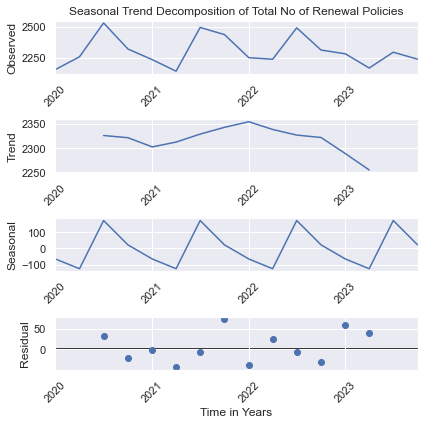

In [57]:
# Seasonal Decomposition of Renewal Business policies

import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
import pandas as pd

# Create PeriodIndex (quarterly)
df_RBD['date'] = pd.PeriodIndex(year=df_RBD['Year'],
                               quarter=df_RBD['Quarter'].str[1:].astype(int),
                               freq='Q')

# Convert PeriodIndex to datetime and set as index
df_RBD = df_RBD.set_index(df_RBD['date'].dt.to_timestamp())

# Run seasonal decomposition (quarterly data → period=4)
decomposition = seasonal_decompose(df_RBD['Number of policies (000s)'], model='additive', period=4)

# Plot decomposition
fig = decomposition.plot()
fig.set_size_inches(6, 6)

fig.axes[0].set_title('Seasonal Trend Decomposition of Total No of Renewal Policies')
fig.axes[0].set_ylabel('Observed')
fig.axes[1].set_ylabel('Trend')
fig.axes[2].set_ylabel('Seasonal')
fig.axes[3].set_xlabel('Time in Years')
fig.axes[3].set_ylabel('Residual')

# -----------------------------
# Customize x-axis ticks: show only years
years = pd.to_datetime(df_RBD['Year'].unique().astype(str))
for ax in fig.axes:
    ax.set_xticks(years)
    ax.set_xticklabels([year.year for year in years], rotation=45)
# -----------------------------

plt.show()


#### Insights

| Aspect              | Interpretation                                                                                                      |
| ------------------- | ------------------------------------------------------------------------------------------------------------------- |
| **Trend**           | Slight decline post-2022                                                                                            |
| **Seasonality**     | Strong yearly pattern (clear repeating peaks & troughs)                                                             |
| **Residuals**       | Small and random → good model fit                                                                                   |
| **Overall insight** | Renewals follow a clear seasonal cycle with mild overall decline — consistent with annual policy renewal behaviour. |


## Business Interpretation (Aligned with UK Market & Weather Factors)

The decomposition plots show that both new and renewal policy volumes display clear annual seasonality and a downward trend after 2021.

This pattern aligns with several real-world factors influencing the UK home-insurance market in recent years:

#### Post-2021 decline in new policy uptake

The fall in new policies after 2021 corresponds with the UK cost-of-living crisis, where rising inflation, energy bills, and mortgage costs reduced household disposable income.

Many customers likely delayed or avoided taking new home-insurance policies, focusing on essential spending instead — matching the gradual decline seen in the trend.

#### Renewal policy decline through 2022–2023

The sharper drop in renewals aligns with increased premium rates driven by high repair and rebuilding costs (materials, labour shortages post-pandemic, and inflation).

Customers became more price-sensitive, often switching providers or reducing cover levels at renewal — consistent with the falling renewal trend.

#### Seasonality in both new and renewal policies

The recurring yearly pattern aligns with weather-linked renewal and claim cycles.

Peaks often occur before or during winter months, when households reassess coverage due to storm and flood risks common in the UK (e.g., Storm Eunice 2022, frequent winter floods).

Dips in summer months reflect a lower perceived risk period, leading to fewer new or renewed policies.

#### Stable residuals

The small, random residuals indicate these effects are systematic and predictable, suggesting that weather seasonality and macroeconomic conditions are the main consistent drivers, not random market shocks.

### Pricing level base - Premium trend

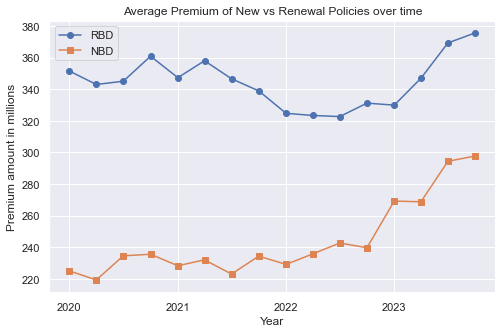

In [139]:
import matplotlib.pyplot as plt
import pandas as pd

# Ensure period column is datetime for both datasets
df_RBD['period'] = pd.PeriodIndex(df_RBD['Year'].astype(str) + df_RBD['Quarter'], freq='Q').to_timestamp()
df_RBD = df_RBD.sort_values('period')

df_NBD['period'] = pd.PeriodIndex(df_NBD['Year'].astype(str) + df_NBD['Quarter'], freq='Q').to_timestamp()
df_NBD = df_NBD.sort_values('period')

plt.figure(figsize=(8,5))

# Plot RBD
plt.plot(df_RBD['period'], df_RBD['Average Premium (£)'], marker='o', label='RBD')

# Plot NBD
plt.plot(df_NBD['period'], df_NBD['Average Premium (£)'], marker='s', label='NBD')

plt.title("Average Premium of New vs Renewal Policies over time")
plt.xlabel("Year")
plt.ylabel("Premium amount in millions")
plt.grid(True)

# ✅ Fix: get unique years across both dfs and convert properly
years = sorted(set(df_RBD['Year']).union(set(df_NBD['Year'])))
years_dt = pd.to_datetime([str(y) for y in years])
plt.xticks(years_dt, [y.year for y in years_dt])

plt.legend()
plt.show()


## Insights based on Number of Policies and Avg premium for New and Renewals

- Renewals have more policies because insurers keep existing customers longer, making renewals a stable revenue source.

- Higher average premiums in renewals often come from add-ons, extra coverages, or loyalty benefits that new policies don’t include.

- New policies are cheaper to attract customers, using discounts or introductory offers, so average premiums are lower.

- Price increases over time (“price walking”) for renewing customers can raise the average premium compared to new business.

- Risk and value differences: renewal customers are usually higher-value and less price-sensitive, while new customers are often more price-conscious.

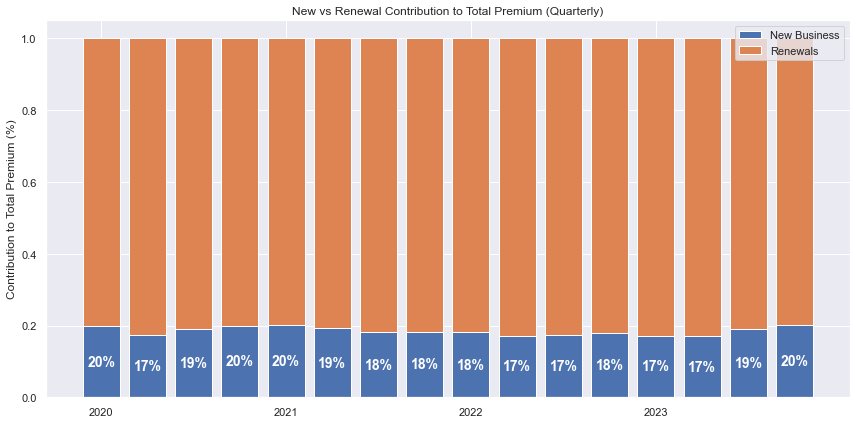

In [72]:
### Revenue Contribution by New and Renewals

import pandas as pd
import matplotlib.pyplot as plt

# --- Step 1: Clean all column names (remove leading/trailing & double spaces) ---
def clean_columns(df):
    df.columns = df.columns.str.strip().str.replace(r"\s+", " ", regex=True)
    return df

df_QTP = clean_columns(df_QTP)
df_NBD = clean_columns(df_NBD)
df_RBD = clean_columns(df_RBD)

# --- Step 2: Create Period column ---
for df in [df_QTP, df_NBD, df_RBD]:
    df["Period"] = df["Year"].astype(str) + "-" + df["Quarter"]

# --- Step 3: Merge dataframes ---
df_merged = df_QTP.merge(df_NBD[["Period", "Written premiums (£m)"]],
                         on="Period", how="inner")
df_merged = df_merged.merge(df_RBD[["Period", "Written premiums (£m)"]],
                            on="Period", how="inner", suffixes=("_New", "_Renewal"))

# --- Step 4: Calculate contributions ---
df_merged["New Contribution"] = (
    df_merged["Written premiums (£m)_New"] / df_merged["Total Written Premium (£m)"]
)
df_merged["Renewal Contribution"] = (
    df_merged["Written premiums (£m)_Renewal"] / df_merged["Total Written Premium (£m)"]
)

# --- Step 5: Plot stacked bar chart ---
fig, ax = plt.subplots(figsize=(12,6))

bars_new = ax.bar(df_merged["Period"], df_merged["New Contribution"], label="New Business")
ax.bar(df_merged["Period"], df_merged["Renewal Contribution"],
       bottom=df_merged["New Contribution"], label="Renewals")

# Format x-axis: show only years at Q1
periods = df_merged["Period"].tolist()
xticks = [i for i, p in enumerate(periods) if p.endswith("Q1")]
xlabels = [p.split("-")[0] for p in periods if p.endswith("Q1")]

ax.set_xticks(xticks)
ax.set_xticklabels(xlabels)

# Labels & legend
ax.set_ylabel("Contribution to Total Premium (%)")
ax.set_title("New vs Renewal Contribution to Total Premium (Quarterly)")
ax.legend()

# --- Step 6: Annotate New Contribution % ---
for bar, value in zip(bars_new, df_merged["New Contribution"]):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2,
            height/2,  # place inside New bar
            f"{value:.0%}",
            ha='center', va='center', color="white", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()


### Conclusion based on revenue and no of policies( new and renewal) trend

#### Renewals are the major revenue contributor

- The stacked bar chart clearly shows that renewals dominate total written premiums each quarter from 2020–2023.

- This indicates the company’s revenue is heavily reliant on retaining existing customers rather than acquiring new ones.

#### Declining number of policies

- Both new business and renewals show a declining trend in the number of policies over 2020–2023.

- This highlights a potential challenge in growing the customer base and future revenue if the trend continues.

#### Increasing average premiums

- Despite fewer policies, the average premium for both new and renewal policies is increasing.

- This is likely a strategic response to maintain revenue and profitability amid declining volumes.

#### Profitability maintained

- The loss ratio analysis suggests that the company remains profitable.

- Increasing premiums compensate for declining policy counts, helping sustain margins and overall profitability.



In [ ]:
## 

In [74]:
## Correlation Analysis

# Clean column names
df_NBD.columns = df_NBD.columns.str.strip()

# Remove commas and convert to numeric
df_NBD["Number of policies (000s)"] = pd.to_numeric(df_NBD["Number of policies (000s)"].astype(str).str.replace(",", ""), errors='coerce')
df_NBD["Average Premium (£)"] = pd.to_numeric(df_NBD["Average Premium (£)"].astype(str).str.replace("£","").str.replace(",",""), errors='coerce')

# Now calculate correlation
corr_new = df_NBD["Average Premium (£)"].corr(df_NBD["Number of policies (000s)"])
print(f"Correlation between Average Premium and Number of New Policies: {corr_new:.2f}")


Correlation between Average Premium and Number of New Policies: -0.56


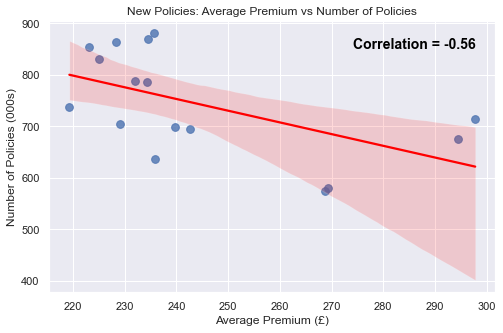

In [83]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure numeric columns
df_NBD["Number of policies (000s)"] = pd.to_numeric(df_NBD["Number of policies (000s)"], errors='coerce')
df_NBD["Average Premium (£)"] = pd.to_numeric(df_NBD["Average Premium (£)"], errors='coerce')

# Calculate correlation
corr_new = df_NBD["Average Premium (£)"].corr(df_NBD["Number of policies (000s)"])

# Scatter plot with regression line
plt.figure(figsize=(8,5))
sns.regplot(x="Average Premium (£)", y="Number of policies (000s)", 
            data=df_NBD, scatter_kws={'s':60}, line_kws={'color':'red'})

# Dynamically position correlation text (top-right of plot)
x_pos = df_NBD["Average Premium (£)"].min() + 0.7*(df_NBD["Average Premium (£)"].max() - df_NBD["Average Premium (£)"].min())
y_pos = df_NBD["Number of policies (000s)"].min() + 0.9*(df_NBD["Number of policies (000s)"].max() - df_NBD["Number of policies (000s)"].min())

plt.text(x_pos, y_pos, f"Correlation = {corr_new:.2f}",
         fontsize=14, color="black", fontweight="bold")

plt.title("New Policies: Average Premium vs Number of Policies")
plt.xlabel("Average Premium (£)")
plt.ylabel("Number of Policies (000s)")
plt.show()



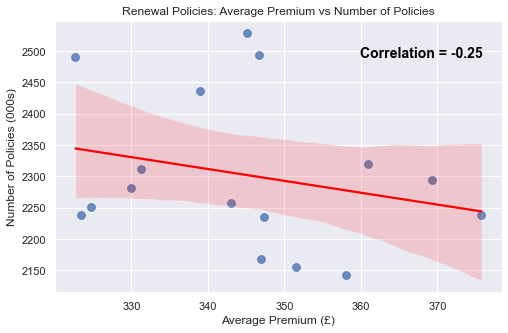

In [82]:

# Corrrelation of No of policies of renewals vs avg premium

corr_new = df_RBD["Average Premium (£)"].corr(df_RBD["Number of policies (000s)"])

# Scatter plot with regression line
plt.figure(figsize=(8,5))
sns.regplot(x="Average Premium (£)", y="Number of policies (000s)", 
            data=df_RBD, scatter_kws={'s':60}, line_kws={'color':'red'})

# Dynamically position correlation text at top-right
x_pos = df_RBD["Average Premium (£)"].min() + 0.7*(df_RBD["Average Premium (£)"].max() - df_RBD["Average Premium (£)"].min())
y_pos = df_RBD["Number of policies (000s)"].min() + 0.9*(df_RBD["Number of policies (000s)"].max() - df_RBD["Number of policies (000s)"].min())

plt.text(x_pos, y_pos, f"Correlation = {corr_new:.2f}",
         fontsize=14, color="black", fontweight="bold")

plt.title("Renewal Policies: Average Premium vs Number of Policies")
plt.xlabel("Average Premium (£)")
plt.ylabel("Number of Policies (000s)")
plt.show()


# Conclusion

New policies show a moderate negative relationship (-0.56): higher average premiums are linked to fewer new customers. This suggests new customers are price-sensitive and more likely to shop around.

Renewals also show a negative relationship (-0.25), but it’s weaker. Existing customers are less price-sensitive, often staying despite price increases due to convenience, loyalty, or inertia.

Some quarters deviate from the trend (dots away from the line), meaning factors like marketing campaigns, seasonality, or external events also influence policy counts beyond just price.

The regression line in both plots gives a quick visual summary: despite fluctuations, the general trend is downward, showing that as premiums rise, policy volumes (both new and renewal) decline — but more sharply for new business.